Frozen lake:


The Default Map (Legend)
If you look at the map itself, it looks like this:


S F F F       (0  1  2  3)
F H F H       (4  5  6  7)
F F F H       (8  9  10 11)
H F F G       (12 13 14 15)

S = Start, F = Frozen (Safe), H = Hole (Game Over), G = Goal (+1 Reward)


Action Mapping
When you see Action: 0, 1, 2, or 3 in the stats, it translates to:
* 0: Left
* 1: Down
* 2: Right
* 3: Up


In [1]:
import gymnasium as gym
import numpy as np


def run_q_learning_with_stats(num_episodes=5, print_steps=True):
    # Reward definition for FrozenLake-v1:
    # - Reach Goal (G): +1
    # - Reach Hole (H): 0
    # - Reach Frozen (F): 0
    # It is a sparse reward system.

    env = gym.make("FrozenLake-v1", is_slippery=False)

    # Initialize Q-table
    Q = np.random.rand(env.observation_space.n, env.action_space.n)

    # Hyperparameters
    alpha = 0.1  # Learning rate
    gamma = 0.99  # Discount factor
    epsilon = 0.1  # Exploration rate

    history = []

    if print_steps:
        print(
            f"{'Episode':<10} | {'Step':<5} | {'State':<5} | {'Action':<6} | {'Reward':<6} | {'Next State':<10}"
        )
        print("-" * 60)

    for episode in range(num_episodes):
        state, _ = env.reset()
        done = False
        step = 0

        while not done:
            # epsilon-greedy action selection
            if np.random.rand() < epsilon:
                action = env.action_space.sample()
            else:
                action = np.argmax(Q[state])

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # Record transition
            transition = {
                "episode": episode,
                "step": step,
                "state": state,
                "action": action,
                "reward": reward,
                "next_state": next_state,
                "done": done,
            }
            history.append(transition)

            # Print stats
            if print_steps:
                print(
                    f"{episode:<10} | {step:<5} | {state:<5} | {action:<6} | {reward:<6.1f} | {next_state:<10}"
                )

            # Q-update
            Q[state, action] += alpha * (
                reward + gamma * np.max(Q[next_state]) - Q[state, action]
            )

            state = next_state
            step += 1

            if done and reward == 1.0:
                if print_steps:
                    print(f"*** Goal reached in episode {episode} at step {step}! ***")
            elif done:
                pass  # Fell into hole or max steps

    return history, Q

In [2]:
logs, Q = run_q_learning_with_stats(num_episodes=100_000, print_steps=False)

In [3]:
import polars as pl

logs_df = pl.DataFrame(logs)
logs_df

episode,step,state,action,reward,next_state,done
i64,i64,i64,i64,i64,i64,bool
0,0,0,0,0,0,false
0,1,0,0,0,0,false
0,2,0,0,0,0,false
0,3,0,0,0,0,false
0,4,0,0,0,0,false
…,…,…,…,…,…,…
99999,1,4,1,0,8,false
99999,2,8,2,0,9,false
99999,3,9,1,0,13,false


/Users/rich/Developer/Github/VariousDataAnalysis/reinforcement_learning/q_learning/.venv/lib/python3.12/site-packages/seaborn/_core/data.py:313: UserWarning: Conversion using Arrow PyCapsule Interface failed due to missing PyArrow>=14 dependency, falling back to (deprecated) interchange protocol. We recommend that you install PyArrow>=14.0.0.
  return pd.api.interchange.from_dataframe(data)


<Axes: xlabel='episode', ylabel='total_reward'>

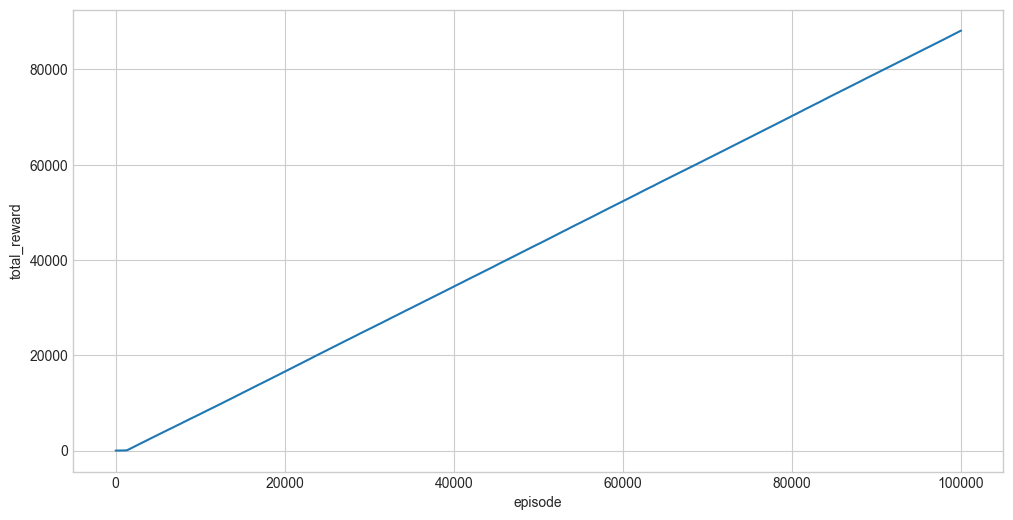

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl

plt.style.use("seaborn-v0_8-whitegrid")
pl.Config.set_fmt_str_lengths(30)

# reward per episode
plot_df = (
    logs_df.group_by("episode")
    .agg(pl.sum("reward").alias("total_reward"))
    .sort("episode")
    .with_columns(pl.col("total_reward").cum_sum())
)
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=plot_df, x="episode", y="total_reward")

In [5]:
Q

array([[1.49829929, 1.51343363, 1.4833163 , 1.49829929],
       [1.49829929, 0.91937182, 1.12794465, 1.4826689 ],
       [1.36969713, 0.10142923, 0.76894889, 0.5606621 ],
       [0.49857374, 0.7775075 , 0.68621769, 0.67466594],
       [1.51343363, 1.52872084, 0.91954716, 1.49829929],
       [0.92883552, 0.10904558, 0.69186979, 0.67240716],
       [0.91954716, 1.55754835, 0.61377552, 0.36525599],
       [0.12096783, 0.1554673 , 0.61792964, 0.78549164],
       [1.52872084, 0.91899825, 1.54416246, 1.51343363],
       [1.52872084, 1.55976006, 1.55976006, 0.91954716],
       [1.54416246, 1.57551521, 0.68878278, 1.53094663],
       [0.39545194, 0.0298518 , 0.5298595 , 0.69574018],
       [0.46346967, 0.92828106, 0.41688458, 0.10322328],
       [0.91899825, 1.55976006, 1.57551521, 1.54416246],
       [1.55976006, 1.57551521, 1.59142951, 1.55976006],
       [0.59740354, 0.00323039, 0.48294981, 0.55625771]])

Policy:

```
S F F F       (0  1  2  3)
F H F H       (4  5  6  7)
F F F H       (8  9  10 11)
H F F G       (12 13 14 15)
```


Action Mapping
When you see Action: 0, 1, 2, or 3 in the stats, it translates to:
* 0: Left
* 1: Down
* 2: Right
* 3: Up


In [6]:
np.argmax(Q, axis=1).reshape(4, 4)

array([[1, 0, 0, 1],
       [1, 0, 1, 3],
       [2, 1, 1, 3],
       [1, 2, 2, 0]])

Value:

In [7]:
np.max(Q, axis=1).reshape(4, 4) / np.max(Q)

array([[0.95099005, 0.94148015, 0.86067094, 0.48855918],
       [0.96059601, 0.58364855, 0.97871024, 0.49357614],
       [0.970299  , 0.9801    , 0.99      , 0.43717939],
       [0.58330015, 0.99      , 1.        , 0.375388  ]])